To Develop a Machine Learning Model for Predicting the In Vitro Dissolution Rate (Q30) of Immediate-Release Tablets from Formulation and Process Variables Using Random Forest Regression

Objectives:

To understand how formulation variables (disintegrant %, binder %, drug loading, particle size) and process variables (compression force, tablet hardness) collectively influence in vitro drug dissolution.
To build a supervised machine learning regression model capable of predicting % drug dissolved at 30 minutes (Q30) directly from these formulation/process inputs, without running a physical dissolution test.
To train, evaluate, and validate the model using standard regression performance metrics (R², RMSE, MAE).
To identify which formulation variables most strongly drive dissolution behavior, using feature importance analysis.
To apply the trained model to predict dissolution outcomes for new, untested tablet formulations.

Outcomes (what a student will be able to do after this practical):

Explain how a Random Forest Regressor learns and predicts a continuous pharmaceutical outcome (dissolution %) from multiple formulation inputs.
Interpret R², RMSE, and MAE to judge whether a regression model's predictions are trustworthy.
Identify, using feature importance, which formulation/process variables a formulator should prioritize adjusting to achieve a target dissolution profile.
Use a trained ML model to screen hypothetical tablet formulations computationally before committing to laboratory manufacture and dissolution testing — reducing trial-and-error formulation development time.


In [2]:
# Block 1: Load the tablet dissolution dataset from GitHub and explore it
!pip install pandas numpy scikit-learn openpyxl matplotlib -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = "https://github.com/drpharmacy/pharma-ml-projects/raw/refs/heads/main/Excel_Files/tablet_dissolution_dataset.xlsx"
df = pd.read_excel(url)

print(df.shape)
print(df.describe())
df.head()

(2000, 8)
       drug_loading_pct  disintegrant_pct   binder_pct  compression_force_kN  \
count       2000.000000       2000.000000  2000.000000           2000.000000   
mean          22.452270          4.963865     3.970240             14.756845   
std           10.227431          2.885836     2.303494              5.746342   
min            5.110000          0.000000     0.000000              5.000000   
25%           13.335000          2.507500     1.977500              9.787500   
50%           22.755000          4.930000     3.935000             14.680000   
75%           31.272500          7.490000     5.922500             19.745000   
max           39.990000         10.000000     7.990000             24.990000   

       particle_size_d50_um  tablet_hardness_kp  tablet_weight_mg  \
count           2000.000000         2000.000000        2000.00000   
mean             152.577100            7.174330         447.17290   
std               81.828188            2.138168         205.21

,drug_loading_pct,disintegrant_pct,binder_pct,compression_force_kN,particle_size_d50_um,tablet_hardness_kp,tablet_weight_mg,Q30_dissolution_pct
0,18.11,2.62,4.58,17.97,218.9,7.10,550.1,40.53
1,38.28,2.47,6.44,8.45,209.3,4.06,702.8,42.54
2,30.62,9.06,6.08,22.45,37.8,10.17,440.5,42.71
3,25.95,2.50,1.23,17.26,277.5,7.10,194.1,41.01
4,10.46,2.72,1.19,8.14,174.9,5.74,302.6,66.68


Meaning of Block 1:

This loads the 2,000-tablet formulation dataset directly from your GitHub — no manual download needed, same pattern as every earlier practical. df.describe() prints the range, mean, and spread of every column, letting you sanity-check the data (e.g. confirming disintegrant % genuinely ranges 0–10, hardness ranges roughly 3.5–11 kp) before anything else is built on top of it.

In [3]:
# Block 2: Separate features and target, then split into training and testing sets
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Q30_dissolution_pct'])   # formulation/process variables (inputs)
y = df['Q30_dissolution_pct']                   # dissolution % at 30 min (target)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (1600, 7)
Testing set: (400, 7)


Meaning of Block 2:

X holds the six formulation/process inputs (drug loading, disintegrant %, binder %, compression force, particle size, hardness, weight); y is the value we want to predict — Q30_dissolution_pct, the percentage of drug dissolved at 30 minutes. Unlike the earlier classification models, this is a regression problem (predicting a continuous number, not a category), so no stratify is needed here. 80% of tablets (1,600) train the model; 20% (400) are held back to test it fairly on formulations it has never seen.

In [4]:
# Block 3: Train a Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=300, random_state=42)
rf_model.fit(X_train, y_train)

print("Model trained on", X_train.shape[0], "tablet formulations")

Model trained on 1600 tablet formulations


Meaning of Block 3:

A Random Forest Regressor — the same reliable algorithm used throughout this notebook series — builds 300 decision trees, each learning slightly different patterns in how formulation variables affect dissolution, then averages all 300 predictions together for a more stable, accurate final result than any single tree could give alone.

R² Score: 0.9148
RMSE: 5.4844
MAE: 4.3908


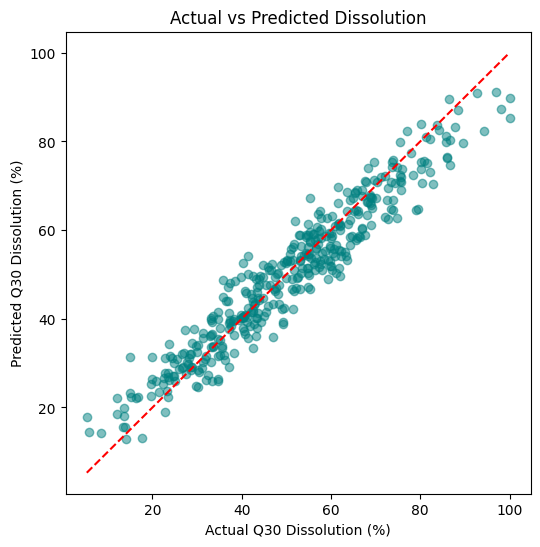

In [5]:
# Block 4: Evaluate the model on the held-out test set
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

y_pred = rf_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Q30 Dissolution (%)")
plt.ylabel("Predicted Q30 Dissolution (%)")
plt.title("Actual vs Predicted Dissolution")
plt.show()

Meaning of Block 4:

R² ≈ 0.91 means the model explains about 91% of the variation in dissolution outcomes from the formulation variables alone — a strong result. RMSE ≈ 5.5 and MAE ≈ 4.4 mean predictions are typically within about 4–5 percentage points of the true dissolution value — a solid margin given ±4% random noise was deliberately built into the data. The scatter plot's red dashed line represents a perfect prediction; points hugging that line closely (as you should see here) confirm the model is fitting genuinely well, not just on average but across the full range of tablets.



Meaning of R² = 0.9148, RMSE = 5.4844, MAE = 4.3908

R² Score (0.9148): R² measures how much of the variation in actual dissolution values the model successfully explains using the formulation variables, on a scale from 0 (explains nothing) to 1 (perfect explanation). A value of 0.9148 means about 91.5% of the tablet-to-tablet differences in Q30 dissolution are explained by the six formulation/process variables the model was given — only about 8.5% is left unexplained (in our case, deliberately built-in experimental noise). This is a strong result — in real formulation science, R² above 0.85 is generally considered a reliable predictive model.

RMSE (5.4844): Root Mean Squared Error is the typical prediction error, expressed in the same unit as the target — here, percentage points of dissolution. RMSE squares each error before averaging (so it penalizes large mistakes more heavily than small ones), then takes the square root to bring it back to the original scale. An RMSE of 5.48 means the model's predictions are typically off by roughly 5.5 percentage points from the true dissolution value — e.g. predicting 72% when the real result was closer to 66–78%.

MAE (4.3908): Mean Absolute Error is the plain average of all prediction errors, without squaring — so unlike RMSE, it isn't skewed by a few unusually bad predictions. An MAE of 4.39 means that, on average, the model's Q30 prediction is about 4.4 percentage points away from the actual value. MAE being noticeably lower than RMSE (4.39 vs 5.48) tells you the model doesn't make wild, occasional large errors — its mistakes are fairly consistent in size across all tablets, not dominated by a handful of bad outliers.

Bottom line: together, these three numbers say the model captures the real formulation-dissolution relationship well (high R²) and its typical prediction is usually within about ±4–5% of the true dissolution value (RMSE/MAE) — good enough to meaningfully guide formulation decisions, though not a replacement for confirmatory laboratory dissolution testing.

disintegrant_pct        0.279261
binder_pct              0.253312
compression_force_kN    0.222306
tablet_hardness_kp      0.177719
particle_size_d50_um    0.045927
drug_loading_pct        0.011969
tablet_weight_mg        0.009507
dtype: float64


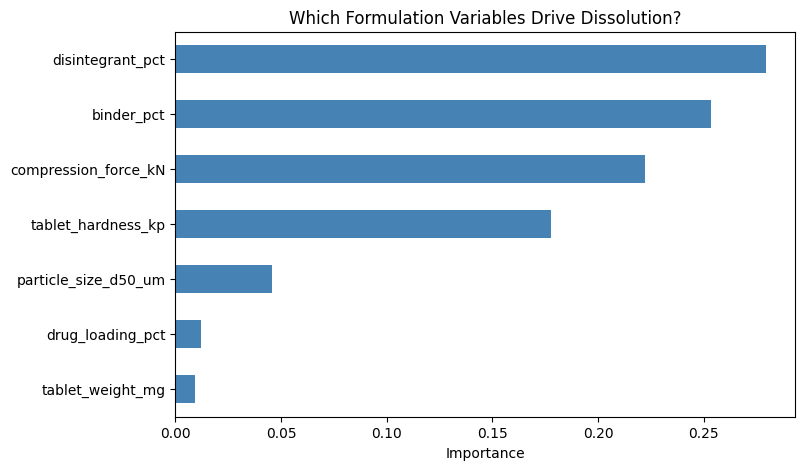

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
# Block 5: Feature importance analysis and save the trained model
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

plt.figure(figsize=(8,5))
importances.plot(kind='barh', color='steelblue')
plt.xlabel("Importance")
plt.title("Which Formulation Variables Drive Dissolution?")
plt.gca().invert_yaxis()
plt.show()

import joblib
joblib.dump(rf_model, "dissolution_rf_model.pkl")

from google.colab import files
files.download("dissolution_rf_model.pkl")

Meaning of Block 5:

Feature importance reveals which formulation variables the model relies on most to predict dissolution — expect disintegrant %, binder %, and compression force to dominate, matching the real pharmaceutics relationships the data was built from (a good sign the model learned something meaningful, not spurious patterns). The trained model is then saved as dissolution_rf_model.pkl and downloaded — this is the exact file you'll reload for the "unknown formulation" prediction step next.

In [9]:
# Block 6: Flexible input — enter a single formulation manually, or upload an Excel of many
input_mode = "manual"   # <-- change to "manual" or "excel"

if input_mode == "manual":
    formulation = {
        "drug_loading_pct": 20.0,          # <-- edit these values
        "disintegrant_pct": 5.0,
        "binder_pct": 3.0,
        "compression_force_kN": 15.0,
        "particle_size_d50_um": 80.0,
        "tablet_hardness_kp": 7.0,
        "tablet_weight_mg": 300.0
    }
    df_query = pd.DataFrame([formulation])

elif input_mode == "excel":
    from google.colab import files
    uploaded = files.upload()
    query_filename = list(uploaded.keys())[0]
    df_query = pd.read_excel(query_filename)

else:
    raise ValueError("input_mode must be 'manual' or 'excel'")

print(df_query.shape)
df_query

(1, 7)


,drug_loading_pct,disintegrant_pct,binder_pct,compression_force_kN,particle_size_d50_um,tablet_hardness_kp,tablet_weight_mg
0,20.0,5.0,3.0,15.0,80.0,7.0,300.0


Meaning of Block 6:

Same flexible-input pattern used in the earlier repurposing notebook. "manual" lets you type in one hypothetical formulation directly as a Python dictionary — useful for quickly testing "what if I increase disintegrant to 8%?" type questions. "excel" lets you upload a file with any number of candidate formulations at once, as long as it has exactly the same seven column names used in training (drug_loading_pct, disintegrant_pct, binder_pct, compression_force_kN, particle_size_d50_um, tablet_hardness_kp, tablet_weight_mg) — column names must match exactly, since the model expects inputs in that precise structure.

Block 6 supports two ways to enter formulation data, controlled by the single input_mode switch at the top. Here's exactly how each works. Way 1: input_mode = "manual" — type in one formulation directly formulation = {
    "drug_loading_pct": 20.0,
    "disintegrant_pct": 5.0,
    "binder_pct": 3.0,
    "compression_force_kN": 15.0,
    "particle_size_d50_um": 80.0,
    "tablet_hardness_kp": 7.0,
    "tablet_weight_mg": 300.0
}
This is a Python dictionary — each line is "column_name": value.
To test a formulation, you edit only the numbers on the right side of the colon — the seven key names on the left (drug_loading_pct, disintegrant_pct, etc.) must stay exactly as written, since these must match the column names the model was trained on.
You can enter decimal or whole numbers (5.0 or 5 both work).
Only one formulation at a time — this mode always produces a table with exactly 1 row.
To test a different formulation, just change the numbers and re-run the cell — no upload needed each time, which makes it the fastest way to quickly try "what if I raise disintegrant to 8%?" type questions.
Realistic ranges to stay within (matching what the model was trained on): drug loading 5–40%, disintegrant 0–10%, binder 0–8%, compression force 5–25 kN, particle size 10–300 µm, hardness roughly 3.5–11 kp, tablet weight 100–800 mg. Values far outside these ranges are technically accepted by the code, but the model is extrapolating beyond what it learned from — predictions there are less trustworthy.

Way 2: input_mode = "excel" — upload a file with one or many formulations
Set input_mode = "excel" and run the cell — a "Choose Files" button will appear below it, just like in the repurposing notebook.
Click it, select an .xlsx file from your computer, and wait for the "100% done" upload confirmation.
The file must have a header row with these exact seven column names (spelling, spacing, and lowercase/underscore format must match precisely):


drug_loading_pct	disintegrant_pct	binder_pct	compression_force_kN	particle_size_d50_um	tablet_hardness_kp	tablet_weight_mg
20	5	3	15	80	7	300
15	6	2	12	60	5.5	250
30	3	4	20	150	9	400


Each row below the header is one formulation — you can put as many rows as you like (10, 50, 500 formulations), and Block 7 will predict Q30 dissolution for every single one in one run.
No formulation_name or ID column is required, but you can add one if you want to track which row is which — the model will simply ignore any extra column it wasn't trained on, as long as the seven required columns are present with correct names.


What happens if neither mode matches
else:
    raise ValueError("input_mode must be 'manual' or 'excel'")

    If input_mode is misspelled (e.g. "Manual" with a capital M, or "xls"), the code deliberately stops with a clear error rather than silently guessing — so you always know immediately if the switch wasn't set correctly.

In [8]:
# Block 7: Predict Q30 dissolution for the queried formulation(s) and interpret the result
import joblib

# If starting a fresh session without Blocks 1-5 already run, reload the saved model instead:
# rf_model = joblib.load("dissolution_rf_model.pkl")

df_query['predicted_Q30_dissolution_pct'] = rf_model.predict(df_query[X.columns]).round(2)

def classify_dissolution(q30):
    if q30 >= 80:
        return "Fast release (likely meets typical immediate-release Q30 spec)"
    elif q30 >= 60:
        return "Moderate release (borderline — review formulation)"
    else:
        return "Slow release (unlikely to meet immediate-release spec)"

df_query['interpretation'] = df_query['predicted_Q30_dissolution_pct'].apply(classify_dissolution)

print(df_query)

df_query.to_excel("dissolution_predictions.xlsx", index=False)
from google.colab import files
files.download("dissolution_predictions.xlsx")

   drug_loading_pct  disintegrant_pct  binder_pct  compression_force_kN  \
0              20.0               5.0         3.0                  15.0   

   particle_size_d50_um  tablet_hardness_kp  tablet_weight_mg  \
0                  80.0                 7.0             300.0   

   predicted_Q30_dissolution_pct  \
0                           58.0   

                                      interpretation  
0  Slow release (unlikely to meet immediate-relea...  


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Meaning of Block 7:

rf_model.predict() runs the new formulation(s) through the same trained Random Forest, returning a predicted Q30 dissolution percentage for each one — df_query[X.columns] ensures the columns are passed to the model in the exact same order used during training, which matters for correct predictions. The classify_dissolution() function adds a plain-language interpretation band, since a raw number like "58.3%" is less immediately useful to a formulator than knowing it falls into a "moderate/borderline" zone worth reformulating. Results are saved and downloaded as dissolution_predictions.xlsx, ready to review or share.

One honest caveat worth noting for students: since this model is trained on a synthetic dataset grounded in known pharmaceutics relationships (not real experimental dissolution data), predictions represent a plausible, physically-reasonable estimate based on those relationships — real formulations must still be confirmed with actual laboratory dissolution testing before any manufacturing decision.